                                                               **Predicción de Cancelación de Clientes (Churn)**

En este proyecto se desarrolla un modelo de Machine Learning para predecir la cancelación de clientes en Telecom X.

El objetivo es identificar patrones que permitan anticipar qué clientes tienen mayor probabilidad de cancelar el servicio y así proponer estrategias de retención.

                                                                    **Carga del Data Set**
En esta sección se carga el dataset previamente limpiado en la Parte 1 del desafío.

In [40]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/marticorenAadriano/Challenge-TelecomX-Alura/refs/heads/main/telecomx_clean.csv")
df.head()

,customerID,Churn,gender,senior,partner,dependents,tenure,phone_service,multiple_lines,internet_service,...,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


                                                                    **Eliminación de variables **

In [41]:
df = df.drop(columns=['customerID'])

                                              **Transformamos las variables categóricas a formato numérico**

In [42]:
X = pd.get_dummies(X, drop_first=True)

                                                     **Calculamos la proporción de clientes que cancelaron**

In [43]:
df['Churn'].value_counts()

,count
Churn,
No,5163
Yes,1869


In [44]:
df['Churn'].value_counts(normalize=True)

,proportion
Churn,
No,0.734215
Yes,0.265785


Se observa que un 73% de clientes cancelaron el serivicio y un 26% de clientes lo mantiene activo

                                                        **Normalizacion de datos**

In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

<Axes: >

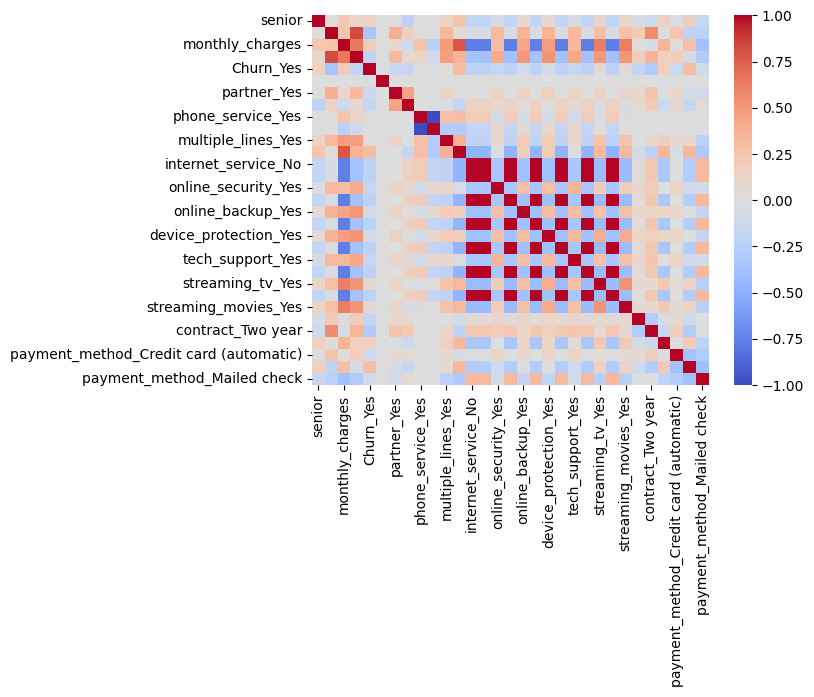

In [47]:
import seaborn as sns

sns.heatmap(df_encoded.corr(), cmap="coolwarm")

                                                 **Análisis de variables vs churn**

<Axes: xlabel='Churn', ylabel='tenure'>

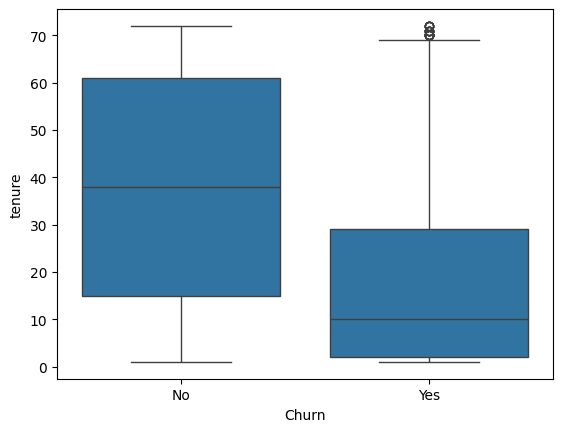

In [48]:
sns.boxplot(x="Churn", y="tenure", data=df)

<Axes: xlabel='Churn', ylabel='monthly_charges'>

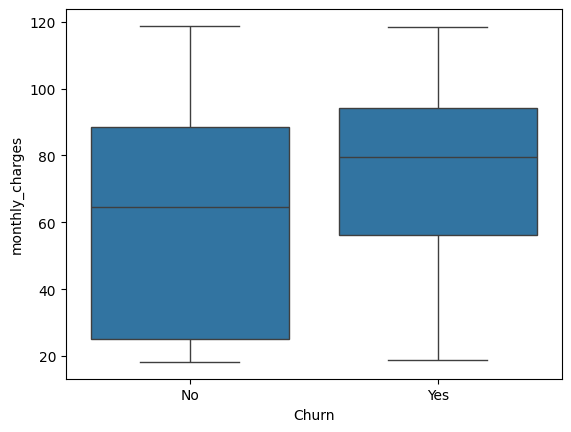

In [50]:
sns.boxplot(x="Churn", y="monthly_charges", data=df)

                                           **Division del data set**

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Divide el conjunto de datos en entrenamiento y prueba

                                                      **Modelos**

Regresión logistica

In [53]:
from sklearn.linear_model import LogisticRegression
LogisticRegression()

LogisticRegression()

In [57]:
from sklearn.linear_model import LogisticRegression

# Crear modelo
model_log = LogisticRegression(max_iter=1000)

# Entrenar modelo
model_log.fit(X_train, y_train)

# Predicciones
y_pred_log = model_log.predict(X_test)

In [58]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy Regresión Logística:")
print(accuracy_score(y_test, y_pred_log))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_log))

Accuracy Regresión Logística:
0.8126721763085399

Reporte de clasificación:
              precision    recall  f1-score   support

       False       0.86      0.90      0.88      1099
        True       0.64      0.53      0.58       353

    accuracy                           0.81      1452
   macro avg       0.75      0.72      0.73      1452
weighted avg       0.80      0.81      0.81      1452



Random forest

In [54]:
RandomForestClassifier()

RandomForestClassifier()

In [59]:
from sklearn.ensemble import RandomForestClassifier

# Crear modelo
model_rf = RandomForestClassifier()

# Entrenar modelo
model_rf.fit(X_train, y_train)

# Predicciones
y_pred_rf = model_rf.predict(X_test)

In [60]:
print("Accuracy Random Forest:")
print(accuracy_score(y_test, y_pred_rf))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_rf))

Accuracy Random Forest:
0.7899449035812672

Reporte de clasificación:
              precision    recall  f1-score   support

       False       0.84      0.90      0.87      1099
        True       0.59      0.46      0.52       353

    accuracy                           0.79      1452
   macro avg       0.71      0.68      0.69      1452
weighted avg       0.78      0.79      0.78      1452



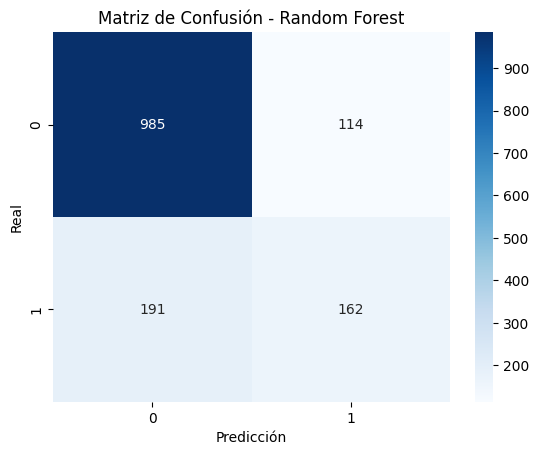

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

Evaluación

Logistica

In [62]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Evaluación - Regresión Logística")

print(f'Accuracy: {accuracy_score(y_test, y_pred_log):.4f}')

print('\nClassification Report:')
print(classification_report(y_test, y_pred_log))

print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred_log))

Evaluación - Regresión Logística
Accuracy: 0.8127

Classification Report:
              precision    recall  f1-score   support

       False       0.86      0.90      0.88      1099
        True       0.64      0.53      0.58       353

    accuracy                           0.81      1452
   macro avg       0.75      0.72      0.73      1452
weighted avg       0.80      0.81      0.81      1452


Confusion Matrix:
[[992 107]
 [165 188]]


Random forest

In [63]:
print("Evaluación - Random Forest")

print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')

print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf))

print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred_rf))

Evaluación - Random Forest
Accuracy: 0.7899

Classification Report:
              precision    recall  f1-score   support

       False       0.84      0.90      0.87      1099
        True       0.59      0.46      0.52       353

    accuracy                           0.79      1452
   macro avg       0.71      0.68      0.69      1452
weighted avg       0.78      0.79      0.78      1452


Confusion Matrix:
[[985 114]
 [191 162]]


Se entrenaron dos modelos de clasificación para predecir la cancelación de clientes: Regresión Logística y Random Forest.

La Regresión Logística obtuvo una accuracy de 81.27%, mientras que Random Forest obtuvo 78.99%.

Analizando el recall para la clase de cancelación (churn), la Regresión Logística logró detectar el 53% de los clientes que cancelaron el servicio, mientras que Random Forest detectó el 46%.

Esto indica que la Regresión Logística tiene un mejor desempeño para identificar clientes con riesgo de cancelación, lo cual es especialmente importante para la empresa, ya que permite aplicar estrategias de retención de forma anticipada.

Por lo tanto, la Regresión Logística se considera el modelo más adecuado para este problema.

                                          **Analisis de variables importantes **

In [64]:
pd.Series(model_rf.feature_importances_, index=X.columns)

,0
senior,0.021597
tenure,0.178782
monthly_charges,0.171424
total_charges,0.190990
gender_Male,0.029756
partner_Yes,0.024573
dependents_Yes,0.019884
phone_service_Yes,0.004172
multiple_lines_No phone service,0.004462
multiple_lines_Yes,0.019444


In [65]:
resultados = {
    "Modelo": ["Regresión Logística", "Random Forest"],
    "Accuracy": [0.8127, 0.7899]
}

import pandas as pd
pd.DataFrame(resultados)

,Modelo,Accuracy
0,Regresión Logística,0.8127
1,Random Forest,0.7899


                                                                   **Conclusión**
                                                                   Conclusiones del Análisis Predictivo de Cancelación (Churn)

A partir del análisis exploratorio de los datos y del entrenamiento de modelos de machine learning, fue posible desarrollar un sistema predictivo capaz de estimar la probabilidad de cancelación de los clientes de Telecom X.

En este proyecto se implementaron dos modelos de clasificación: Regresión Logística y Random Forest, con el objetivo de comparar su desempeño en la predicción del churn.

Los resultados obtenidos muestran que el modelo de Regresión Logística presentó un mejor rendimiento general, alcanzando una exactitud (accuracy) de 81.27%, mientras que el modelo Random Forest obtuvo una accuracy de 78.99%.

Además de la accuracy, se analizaron métricas clave como precision, recall y F1-score, especialmente para la clase correspondiente a clientes que cancelan el servicio. En este aspecto, la Regresión Logística logró detectar el 53% de los clientes que cancelaron, mientras que Random Forest detectó el 46%.

Esto indica que el modelo de Regresión Logística tiene una mayor capacidad para identificar clientes con riesgo de cancelación, lo cual resulta fundamental para implementar estrategias de retención de manera anticipada.

El análisis de la matriz de confusión también permitió observar que el modelo logra identificar correctamente una proporción importante de clientes que cancelan, aunque todavía existen casos en los que la cancelación no es detectada por el modelo.

En conclusión, la Regresión Logística se presenta como el modelo más adecuado para este problema, ya que ofrece un mejor equilibrio entre capacidad predictiva y detección de clientes en riesgo de cancelación.

                                                                 Factores que influyen en la cancelación

A partir del análisis de las variables del dataset y de su relación con la cancelación, se identificaron algunos factores que parecen tener mayor influencia en el churn de los clientes:

Tipo de contrato: los clientes con contratos mensuales tienden a cancelar con mayor frecuencia que aquellos con contratos anuales o de mayor duración.

Antigüedad del cliente (tenure): los clientes con menor tiempo en la empresa presentan una mayor probabilidad de cancelar el servicio.

Cargos mensuales (MonthlyCharges): niveles altos de gasto mensual pueden aumentar la probabilidad de cancelación.

Servicios adicionales contratados: la falta de servicios complementarios puede estar asociada con menor fidelización del cliente.

Estos factores pueden utilizarse para identificar perfiles de clientes con mayor riesgo de abandono.

                                                               Estrategias de Negocio para Reducir el Churn

Con base en los resultados obtenidos y en los factores que influyen en la cancelación, se pueden proponer diversas estrategias orientadas a mejorar la retención de clientes.

1️- Incentivar contratos de mayor duración

Los datos muestran que los clientes con contratos mensuales tienen mayor probabilidad de cancelar.
Por lo tanto, la empresa podría ofrecer descuentos o beneficios especiales para contratos anuales o de largo plazo, incentivando así la permanencia de los clientes.

2️- Programas de fidelización para nuevos clientes

Los clientes con menor antigüedad presentan mayor riesgo de cancelación.
Una estrategia efectiva podría ser implementar programas de fidelización durante los primeros meses del servicio, como beneficios exclusivos, soporte prioritario o promociones especiales.

3️- Optimización de planes y precios

Dado que los cargos mensuales elevados pueden aumentar la probabilidad de cancelación, la empresa podría analizar su estructura de precios y ofrecer planes más flexibles o personalizados, ajustados a las necesidades de cada cliente.

4️- Ofrecer servicios adicionales

Promover la contratación de servicios complementarios puede aumentar el nivel de compromiso del cliente con la empresa, reduciendo así la probabilidad de cancelación.

5️- Uso del modelo predictivo para acciones preventivas

El modelo desarrollado puede integrarse en los sistemas de la empresa para identificar clientes con alto riesgo de churn en tiempo real.
Esto permitiría implementar acciones preventivas, como ofertas personalizadas o contacto proactivo del equipo de atención al cliente.

                                                                 Conclusión estratégica

El uso de modelos predictivos de machine learning permite a Telecom X anticipar el comportamiento de sus clientes y tomar decisiones basadas en datos.

Implementar estrategias de retención basadas en los resultados del modelo puede ayudar a reducir significativamente la tasa de cancelación, mejorar la satisfacción del cliente y aumentar la rentabilidad a largo plazo.                                                                   